<a href="https://colab.research.google.com/github/kyjness/personal/blob/Code/4%EC%A3%BC%EC%B0%A8_%EB%AF%B8%EC%85%98_jessie_07%ED%8C%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 한글폰트 사용을 위해 설치
# 아래 모듈을 설치하고 불러오면 별도의 한글폰트 설정이 필요 없습니다.
!pip install koreanize-matplotlib

import koreanize_matplotlib

df = pd.read_csv(
    "https://raw.githubusercontent.com/corazzon/boostcourse-ds-510/master/data/online_oversea_sale_202210.csv.zip",
    encoding="cp949")

# 에러 메세지 무시
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#데이터 현황 확인
print(df.shape)
df.head()
df.describe(include="object")
df["판매유형별"].value_counts()

(2772, 5)


,count
판매유형별,
면세점 이외,2772


#📌 Q1. 시점 컬럼에서 연도와 분기에 대한 파생변수를 생성하고 기술통계를 구해주세요.

*   데이터 컬럼을 단위인 "백만"으로 변경해 주세요.
*   describe() 로 기술통계를 구했을 때 다음과 같은 결과가 나오도록 합니다. 아래 결과는 예시로 소숫점 자리수가 다르게 표시되더라도 값이 같다면 괜찮습니다.

*  전처리한 백만, 연도, 분기 컬럼이 수치형 데이터 일 때 아래와 같은 결과가 나오니 데이터가 수치 형태로 되어 있는지도 확인해 주세요!
*  데이터는 위에서 제공된 데이터를 사용합니다.

* 해당 기술통계로 알 수 있는 정보가 무엇인지도 함께 작성해 주세요!







In [ ]:
df

,국가(대륙)별,상품군별,판매유형별,시점,데이터
0,미국,컴퓨터 및 주변기기,면세점 이외,2017.1/4,1054
1,미국,컴퓨터 및 주변기기,면세점 이외,2017.2/4,946
2,미국,컴퓨터 및 주변기기,면세점 이외,2017.3/4,791
3,미국,컴퓨터 및 주변기기,면세점 이외,2017.4/4,854
4,미국,컴퓨터 및 주변기기,면세점 이외,2018.1/4,2033
...,...,...,...,...,...
2767,기타,기 타,면세점 이외,2021.2/4,1278
2768,기타,기 타,면세점 이외,2021.3/4,1154
2769,기타,기 타,면세점 이외,2021.4/4,1076
2770,기타,기 타,면세점 이외,2022.1/4,2325


In [ ]:
# 시점에서 연도와 분기 추출
df['연도'] = df['시점'].map(lambda x : int (x.split('.')[0]))
df['분기'] = df['시점'].map(lambda x : int (x.split('.')[1].split('/')[0]))

# 데이터 단위를 백만 단위로 변환
df['백만'] = df['데이터'].copy()

# 수치형 데이터로 변환한 후 describe()로 기술 통계 구하기
summary = df[['백만', '연도', '분기']].describe().astype(int)

# 결과 출력
summary

,백만,연도,분기
count,2772,2772,2772
mean,1613,2019,2
std,4273,1,1
min,-10003,2017,1
25%,41,2018,1
50%,291,2019,2
75%,1181,2021,3
max,47689,2022,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   국가(대륙)별  2772 non-null   object
 1   상품군별     2772 non-null   object
 2   판매유형별    2772 non-null   object
 3   시점       2772 non-null   object
 4   데이터      2772 non-null   int64 
 5   연도       2772 non-null   int64 
 6   분기       2772 non-null   int64 
 7   백만       2772 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 173.4+ KB


In [ ]:
df #백만,연도,분기 추가된 것 확인

,국가(대륙)별,상품군별,판매유형별,시점,데이터,연도,분기,백만
0,미국,컴퓨터 및 주변기기,면세점 이외,2017.1/4,1054,2017,1,1054
1,미국,컴퓨터 및 주변기기,면세점 이외,2017.2/4,946,2017,2,946
2,미국,컴퓨터 및 주변기기,면세점 이외,2017.3/4,791,2017,3,791
3,미국,컴퓨터 및 주변기기,면세점 이외,2017.4/4,854,2017,4,854
4,미국,컴퓨터 및 주변기기,면세점 이외,2018.1/4,2033,2018,1,2033
...,...,...,...,...,...,...,...,...
2767,기타,기 타,면세점 이외,2021.2/4,1278,2021,2,1278
2768,기타,기 타,면세점 이외,2021.3/4,1154,2021,3,1154
2769,기타,기 타,면세점 이외,2021.4/4,1076,2021,4,1076
2770,기타,기 타,면세점 이외,2022.1/4,2325,2022,1,2325


#📌 Q2. pivot_table을 사용하여 국가(대륙)별 연도별 판매액의 합계를 분석해 주세요.

*  국가(대륙)별 연도별 판매액의 합계를 구해서 어느 지역에 판매액이 많은지를 알아보겠습니다.
*   pivot_table 을 사용하여 다음의 결과를 구하고 시각화 해주세요!

*   그래프의 색상, 스타일은 자유롭게 원하는 스타일로 지정해도 됩니다.





In [ ]:
# df_2 정의
df_2 = df[['국가(대륙)별','시점','데이터']]

# 연도만 추출
for i in range(len(df_2)):
    df_2['시점'][i]= df_2['시점'][i].split('.')[0]
# pivot_table 사용
df_2 = df_2.pivot_table(index='국가(대륙)별', columns='시점', values='데이터', aggfunc='sum')

In [ ]:
df_2.index

Index(['기타', '대양주', '미국', '아세안(ASEAN)', '유럽연합(EU)', '일본', '중국', '중남미', '중동'], dtype='object', name='국가(대륙)별')

In [ ]:
# index 초기화
df_2 = df_2.reset_index()
# 칼럼 이름 없애기
df_2.keys().name=None
df_2

,국가(대륙)별,2017,2018,2019,2020,2021,2022
0,기타,41571,36141,40950,44438,57959,19501
1,대양주,18989,17520,13191,16255,16841,5044
2,미국,142292,156312,186617,255384,277579,103416
3,아세안(ASEAN),66163,76450,82930,105360,94150,38072
4,유럽연합(EU),31068,36826,39008,39865,32349,9019
5,일본,125442,178094,189330,220730,280029,131771
6,중국,167240,182068,210418,289446,194380,98572
7,중남미,10245,11669,12981,12563,8298,2629
8,중동,8030,8019,9325,11467,6164,1389


In [ ]:
df_2.keys()

Index(['국가(대륙)별', '2017', '2018', '2019', '2020', '2021', '2022'], dtype='object')

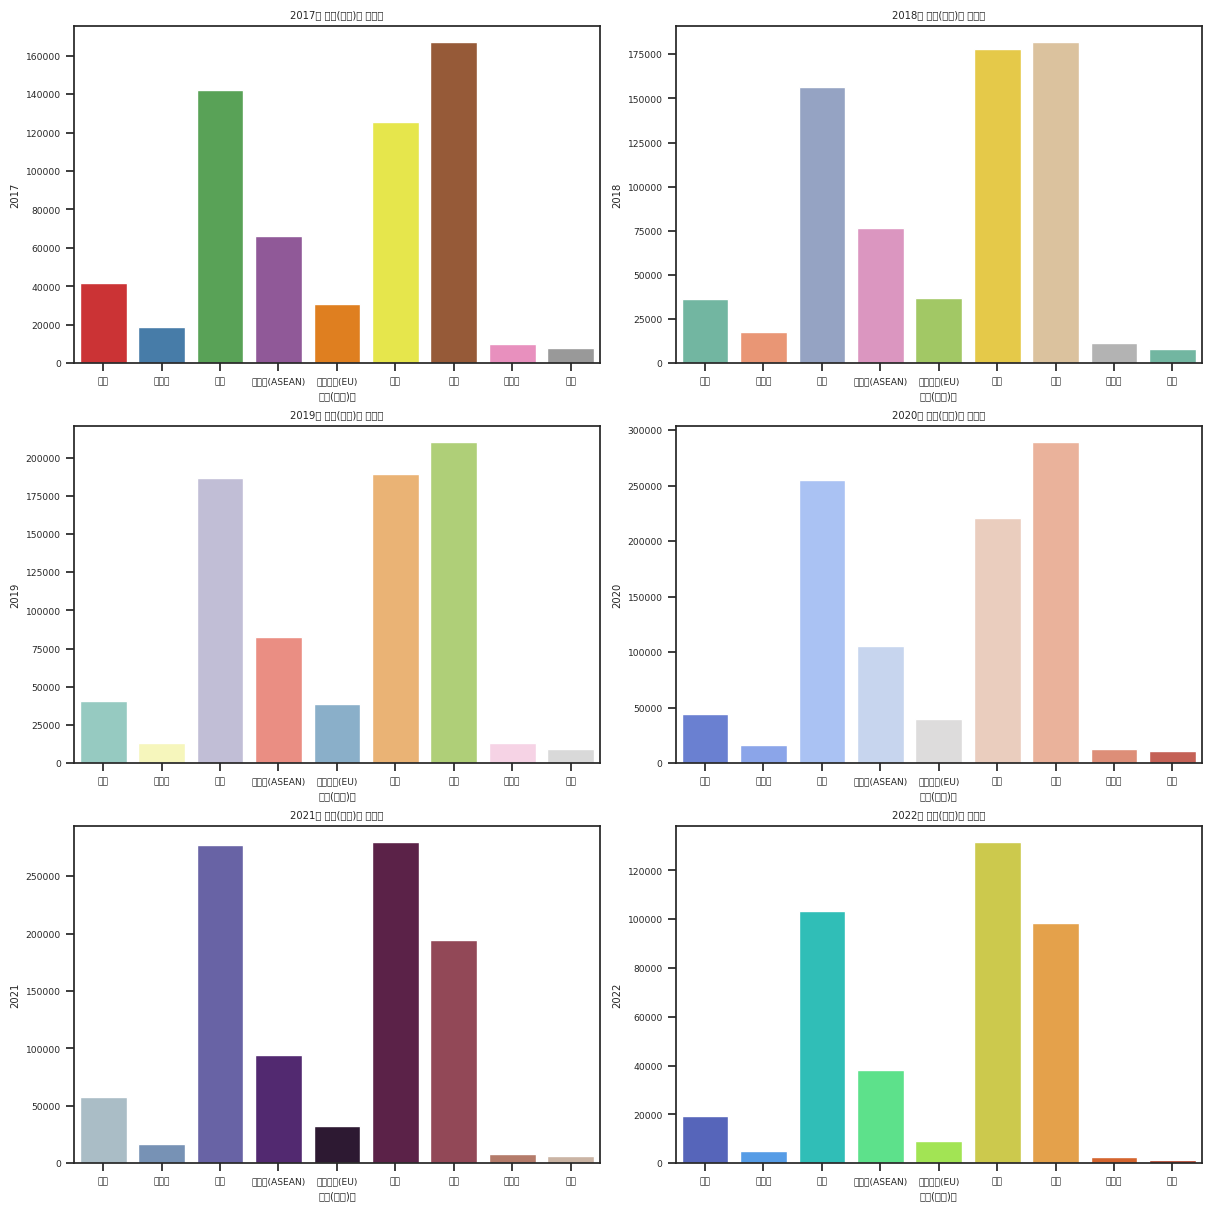

In [ ]:
# D2coding 폰트 설정
sns.set_theme(font="D2Coding", style="ticks",font_scale=0.6)

# 그래프 그리기

# 연도별 subplot
fig, axes = plt.subplots(3, 2, constrained_layout=True, figsize=(12, 12))


# 2017
sns.barplot(ax=axes[0, 0], data=df_2, x='국가(대륙)별', y='2017', palette="Set1")
axes[0, 0].set_title('2017년 국가(대륙)별 판매액')

# 2018
sns.barplot(ax=axes[0, 1], data=df_2, x='국가(대륙)별', y='2018', palette="Set2")
axes[0, 1].set_title('2018년 국가(대륙)별 판매액')

# 2019
sns.barplot(ax=axes[1, 0], data=df_2, x='국가(대륙)별', y='2019', palette="Set3")
axes[1, 0].set_title('2019년 국가(대륙)별 판매액')

# 2020
sns.barplot(ax=axes[1, 1], data=df_2, x='국가(대륙)별', y='2020', palette="coolwarm")
axes[1, 1].set_title('2020년 국가(대륙)별 판매액')

# 2021
sns.barplot(ax=axes[2, 0], data=df_2, x='국가(대륙)별', y='2021', palette="twilight")
axes[2, 0].set_title('2021년 국가(대륙)별 판매액')

# 2022
sns.barplot(ax=axes[2, 1], data=df_2, x='국가(대륙)별', y='2022', palette="turbo")
axes[2, 1].set_title('2022년 국가(대륙)별 판매액')

plt.show()

#📌 Q3. groupby를 사용하여 2020년의 온라인 해외판매 상품군을 지역별 합계를 구해 분석해 주세요.

*   2020년은 코로나로 인해 전국민이 어려움을 겪었던 시기입니다. 또, 아마존 등의 해외 온라인 판매가 늘어난 시기이기도 합니다. 이 때, 해외 어느지역에 온라인 판매가 얼마나 되었는지를 groupby() 와 unstack()을 활용해서 합계를 구하고 분석해 주세요! 또 분석한 결과를 보고 어떤 인사이트를 얻었는지도 함께 작성해 주세요!
*  그래프의 색상, 스타일은 자유롭게 원하는 스타일로 지정해도 됩니다.



In [ ]:
df

,국가(대륙)별,상품군별,판매유형별,시점,데이터
0,미국,컴퓨터 및 주변기기,면세점 이외,2017.1/4,1054
1,미국,컴퓨터 및 주변기기,면세점 이외,2017.2/4,946
2,미국,컴퓨터 및 주변기기,면세점 이외,2017.3/4,791
3,미국,컴퓨터 및 주변기기,면세점 이외,2017.4/4,854
4,미국,컴퓨터 및 주변기기,면세점 이외,2018.1/4,2033
...,...,...,...,...,...
2767,기타,기 타,면세점 이외,2021.2/4,1278
2768,기타,기 타,면세점 이외,2021.3/4,1154
2769,기타,기 타,면세점 이외,2021.4/4,1076
2770,기타,기 타,면세점 이외,2022.1/4,2325


In [ ]:
# 2020년 데이터 필터링
df_3 = df[df['시점'].str.contains('2020')]

# 국가(대륙)별, 상품군별 데이터 합계 계산
df_3 = df_3.groupby(by=['국가(대륙)별', '상품군별'])['데이터'].sum().unstack()
# unstack() ->

# 결과 확인
df_3

상품군별,가전·전자·통신기기,기 타,농축수산물,사무·문구,생활용품 및 자동차용품,서 적,소프트웨어,스포츠·레저용품,아동·유아용품,음·식료품,음반·비디오·악기,의류 및 패션 관련상품,컴퓨터 및 주변기기,화장품
국가(대륙)별,,,,,,,,,,,,,,
기타,1716,3345,9,187,1464,4563,21,755,1646,1596,1410,6501,5653,15572
대양주,3825,923,1,21,1198,367,20,690,484,403,1800,3746,318,2459
미국,10103,38731,33,398,11467,9709,865,5862,4934,2706,32919,82154,6057,49446
아세안(ASEAN),12405,2620,17,3279,6432,4192,3,7423,2698,4291,16135,37992,541,7332
유럽연합(EU),3040,3907,0,25,2560,514,99,1297,1354,423,12092,5120,1910,7524
일본,404,30509,2,1526,3911,1055,27,646,1353,4699,14738,119452,193,42215
중국,1353,22736,88,403,7142,6659,4,3999,5606,4220,125078,73068,235,38855
중남미,912,625,0,3,1361,188,15,183,151,774,6421,614,362,954
중동,839,533,0,4,1060,139,17,196,121,927,3250,1776,388,2217


<Figure size 1400x800 with 0 Axes>

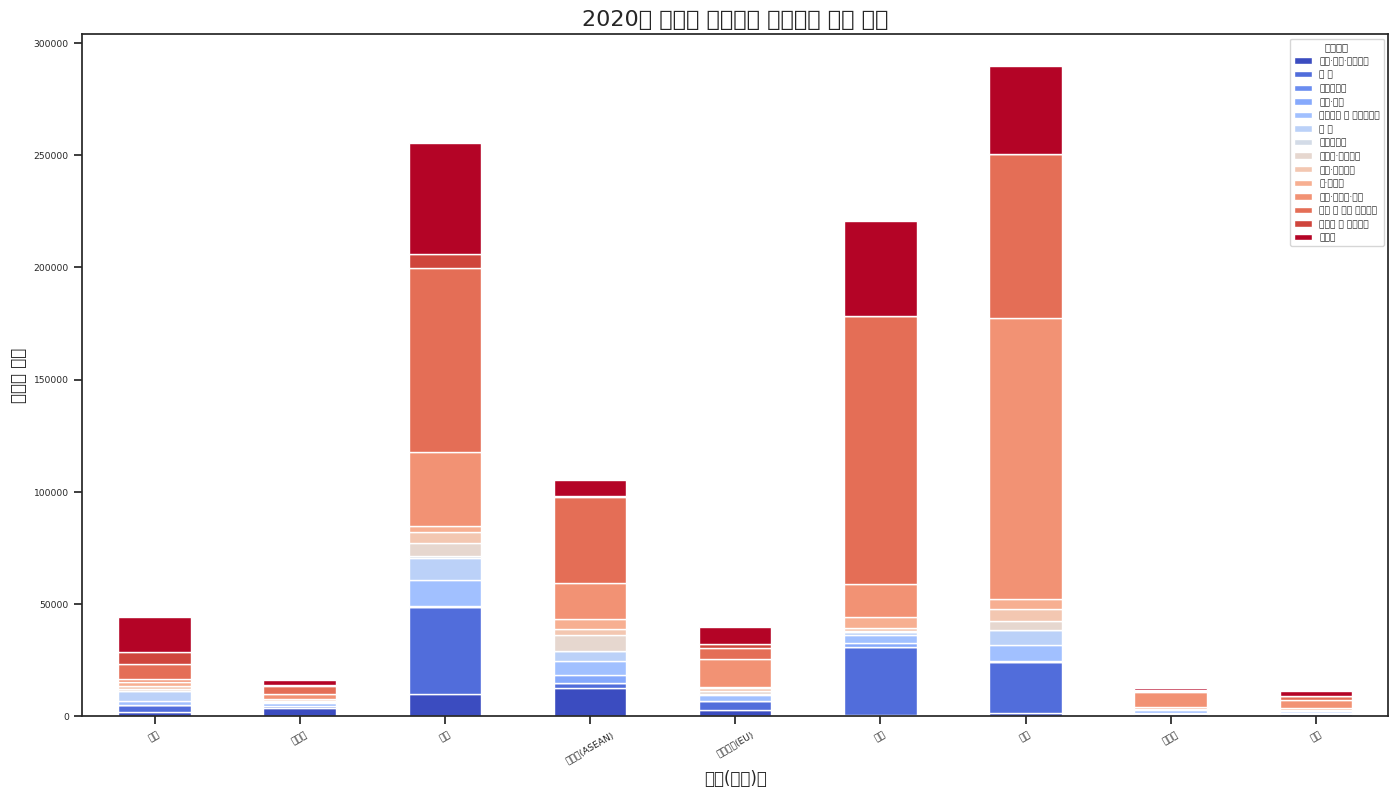

In [ ]:
plt.figure(figsize=(14, 8))

# 누적 막대 그래프 생성
df_3.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(14, 8),rot=30)

# 그래프 제목 및 레이블 설정
plt.title('2020년 온라인 해외판매 상품군별 지역 합계', fontsize=16)
plt.xlabel('국가(대륙)별', fontsize=12)
plt.ylabel('판매액 합계', fontsize=12)
plt.legend(title='상품군별')

plt.tight_layout()
plt.show()

#📌 Q4. 주요 판매 국가와 상품군에 대해 2021년까지의 연도별 온라인 직접 판매액 합계를 시각화 해주세요.

*  온라인 직접 판매액이 높은 지역은 "미국", "중국", "일본" 이며, 주요 판매 상품군은 "의류 및 패션 관련상품", "화장품", "음반·비디오·악기" 입니다. 2021년까지의 각 지역별 제품별 판매액을 시각화 해주세요!
*   시각화 결과의 색상이나 스타일이나 스타일은 달라도 괜찮습니다.



#📌 Q5. KOSIS 에 있는 데이터를 하나 정해 자유롭게 분석해 주세요!

*  지금까지 익힌 방법으로 다른 데이터에도 같은 방법을 통해 분석해 볼 수 있을 것입니다.
*   KOSIS(https://kosis.kr/) 사이트에서 관심있는 분야의 데이터를 찾고 원하는 시각화를 해주세요!

*  조회조건에 계, 합계 등을 미리 제거하고 다운로드 받으면 전처리를 줄일 수 있습니다.
*   행렬전환 기능을 사용하면 따로 melt를 진행하지 않아도 되기 때문에 이 또한 전처리를 줄일 수 있습니다.



